In [1]:
import os
import numpy as np
import pandas as pd
import skimage.io as io
import seaborn as sns
import matplotlib.pyplot as plt

# makes figures look better in Jupyter
sns.set_context('talk')
sns.set_style("ticks")
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [5]:
final_df=pd.read_csv('/Volumes/salmonella/users/madison/2025_beadanalysis/full_pHrodo.csv')

In [6]:
#sorting out the phrodo beads from no bead controls
final_df_bead = final_df[final_df['beads']==True]
final_df_bead['dose_rep'] = final_df_bead['dose'].astype('string')+final_df_bead['replicate'].astype('string')

/var/folders/46/k335xc3d451dkz01yv9q72sc0000gr/T/ipykernel_17580/1117688242.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df_bead['dose_rep'] = final_df_bead['dose'].astype('string')+final_df_bead['replicate'].astype('string')


<Axes: xlabel='nuclei_count', ylabel='Count'>

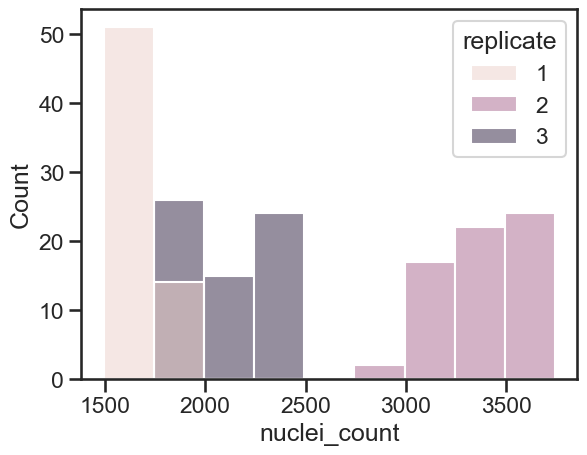

In [9]:
#Getting count of nuclei per dose/hours and plotting that across replicates
sum_nucs = final_df_bead.groupby(['replicate', 'dose', 'Hours'])['nuclei_count'].sum()
sum_nucs_df = final_df_bead.groupby(['replicate', 'dose', 'Hours'], as_index = False)['nuclei_count'].sum()
sns.histplot(data = sum_nucs_df, x = 'nuclei_count', hue = 'replicate')

<Axes: xlabel='Hours', ylabel='total_int/cell#'>

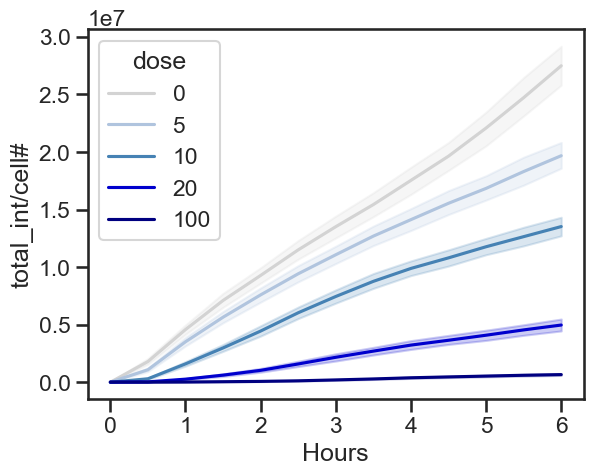

In [12]:
palette = {0:'lightgrey', 5:'lightsteelblue', 10:'steelblue', 20:'mediumblue', 100:'navy'}
sns.lineplot(data = final_df_bead, x='Hours', y='total_int/cell#', hue='dose', palette = palette)

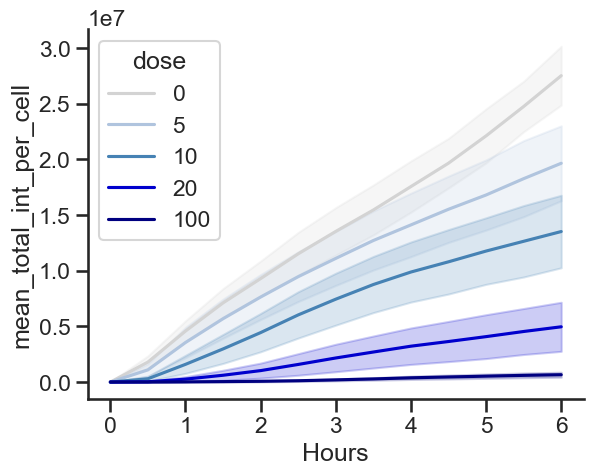

In [52]:
palette = {0:'lightgrey', 5:'lightsteelblue', 10:'steelblue', 20:'mediumblue', 100:'navy'}
sns.lineplot(data = grouped_df, x='Hours', y='mean_total_int_per_cell', hue='dose', palette = palette, errorbar='sd')
sns.despine()

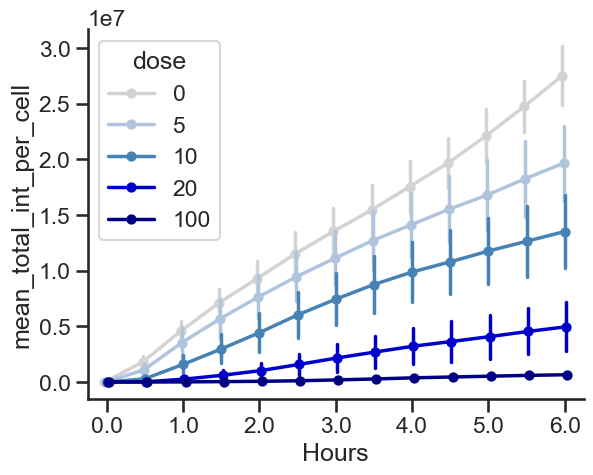

In [87]:
palette = {0:'lightgrey', 5:'lightsteelblue', 10:'steelblue', 20:'mediumblue', 100:'navy'}
ax = sns.pointplot(data = grouped_df, x='Hours', y='mean_total_int_per_cell', hue='dose', palette = palette, linewidth = 2.5, errorbar='sd', dodge = True, markersize=5.5)
sns.despine()
ax.set_xticks([0, 2, 4, 6, 8, 10, 12])
plt.savefig(output+'/meantotalint_pointplot.pdf')

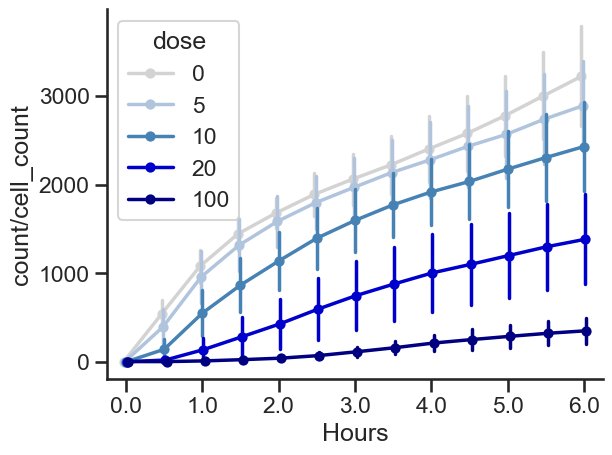

In [113]:
palette = {0:'lightgrey', 5:'lightsteelblue', 10:'steelblue', 20:'mediumblue', 100:'navy'}
ax = sns.pointplot(data = grouped_df, x='Hours', y='count/cell_count', hue='dose', palette = palette, linewidth = 2.5, errorbar='sd', dodge = True, markersize=5.5)
sns.despine()
ax.set_xticks([0, 2, 4, 6, 8, 10, 12])
plt.savefig(output+'/count_pointplot.pdf')

<Axes: xlabel='Hours', ylabel='mean_total_int_per_cell'>

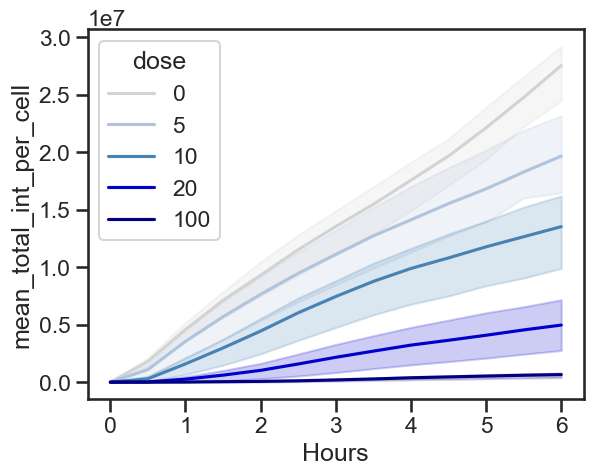

In [66]:
palette = {0:'lightgrey', 5:'lightsteelblue', 10:'steelblue', 20:'mediumblue', 100:'navy'}
sns.lineplot(data = grouped_df, x='Hours', y='mean_total_int_per_cell', hue='dose', palette = palette)